   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

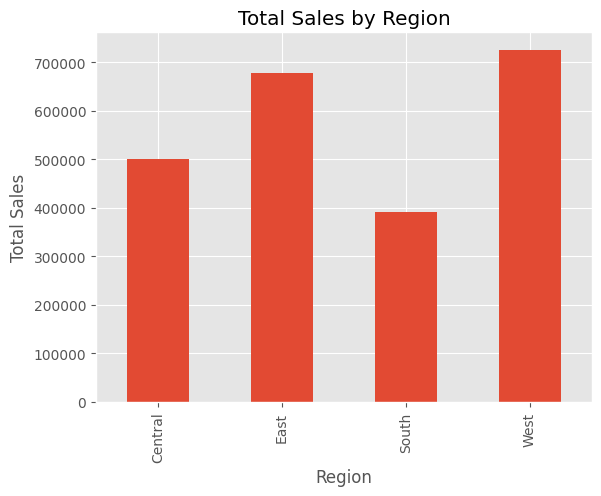

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


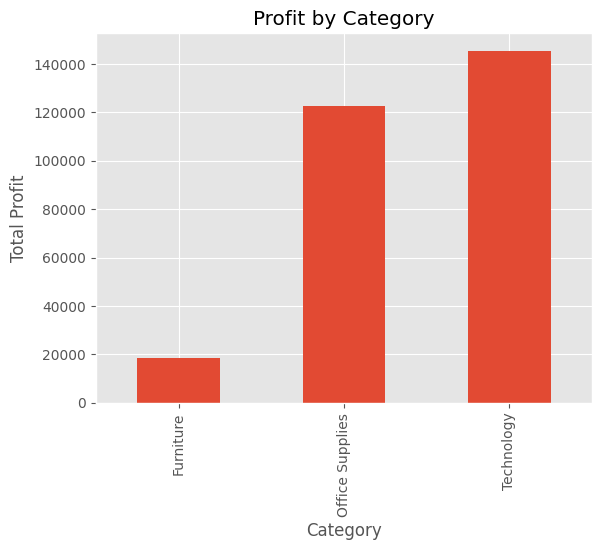

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


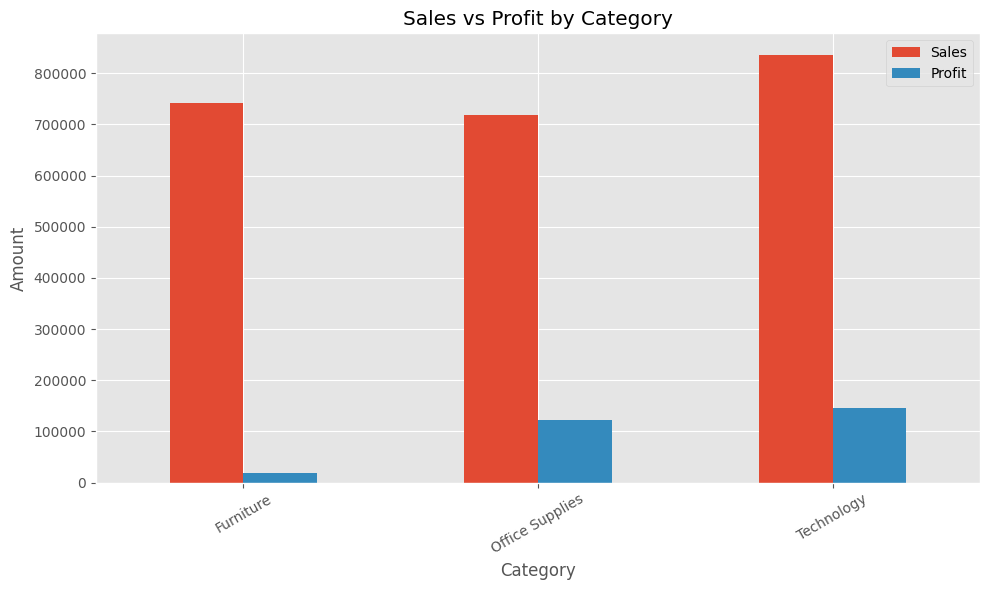

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


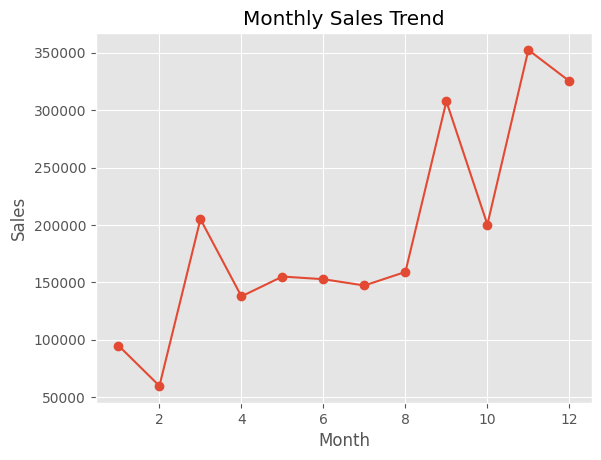

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


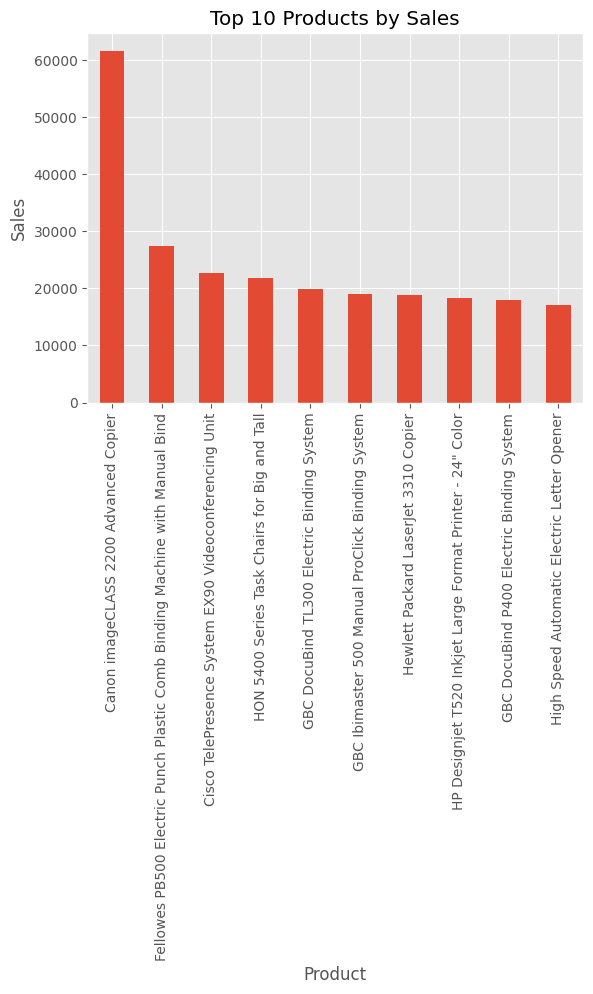

             Sales    Profit  Quantity  Discount
Sales     1.000000  0.479064  0.200795 -0.028190
Profit    0.479064  1.000000  0.066253 -0.219487
Quantity  0.200795  0.066253  1.000000  0.008623
Discount -0.028190 -0.219487  0.008623  1.000000


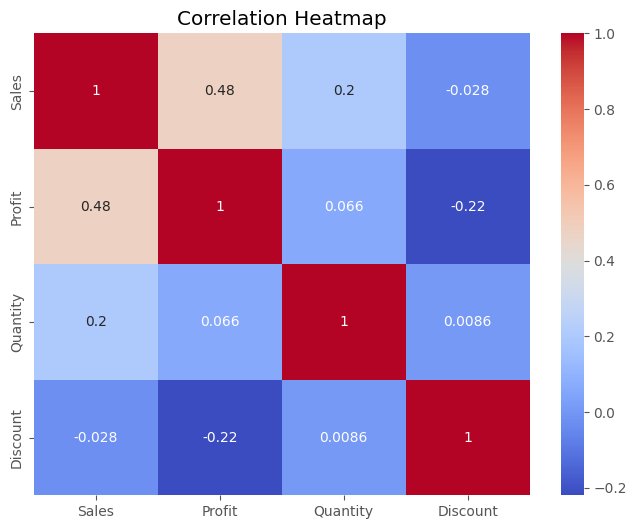

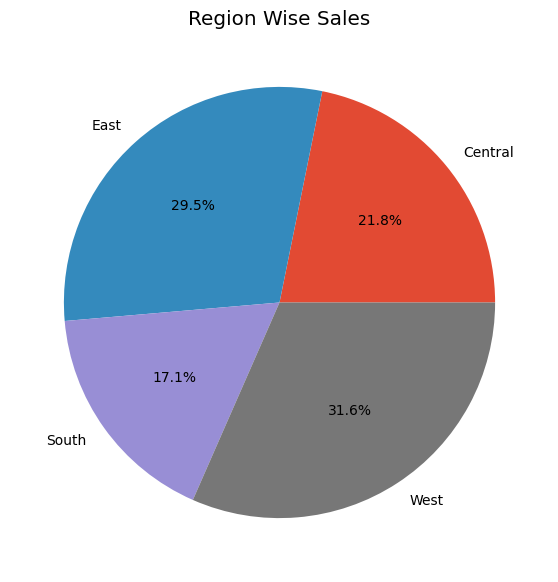

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


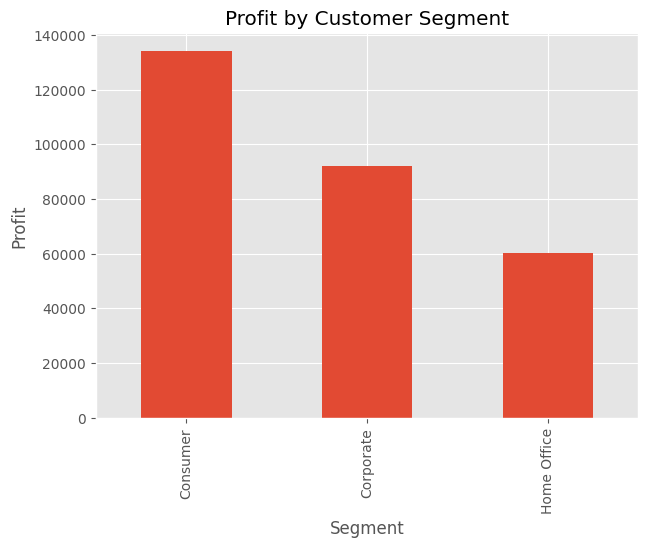

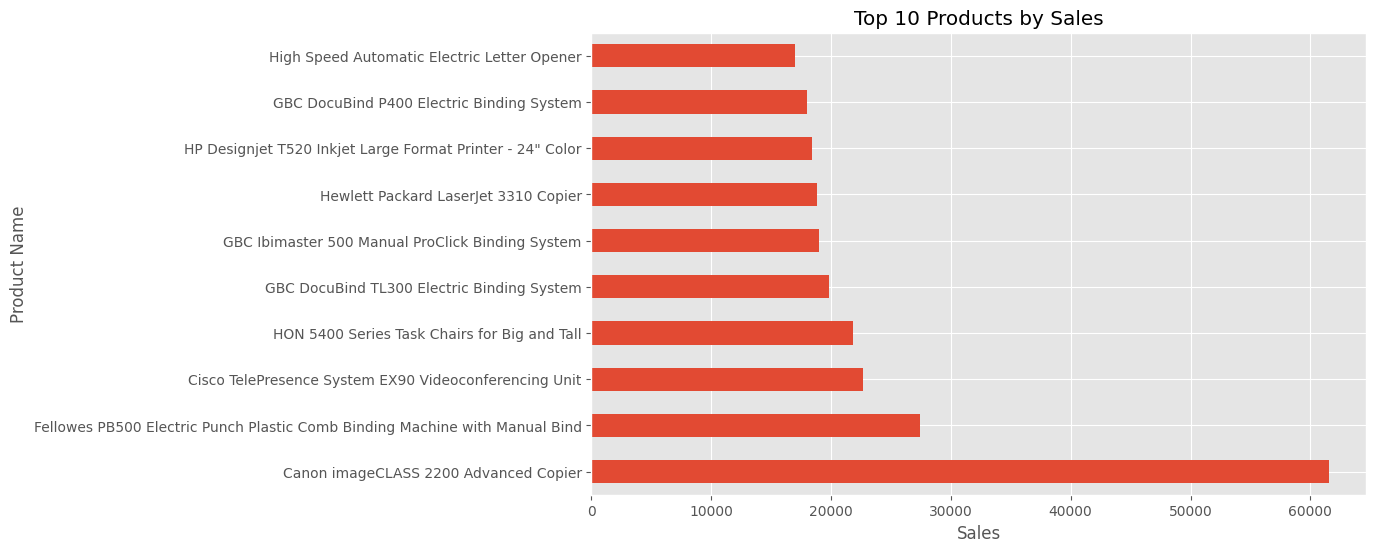

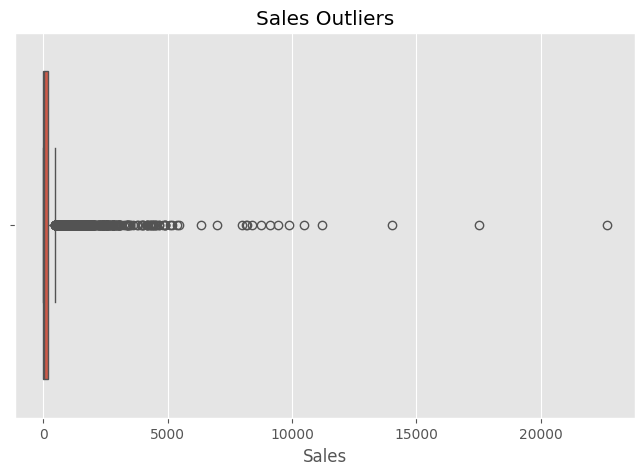

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


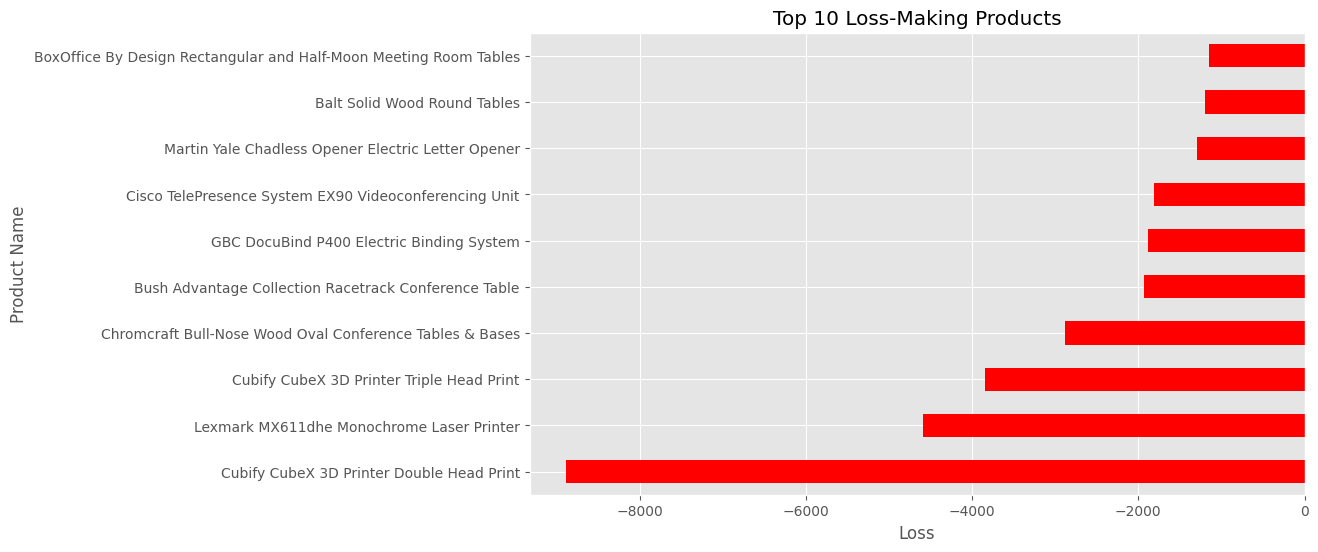

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


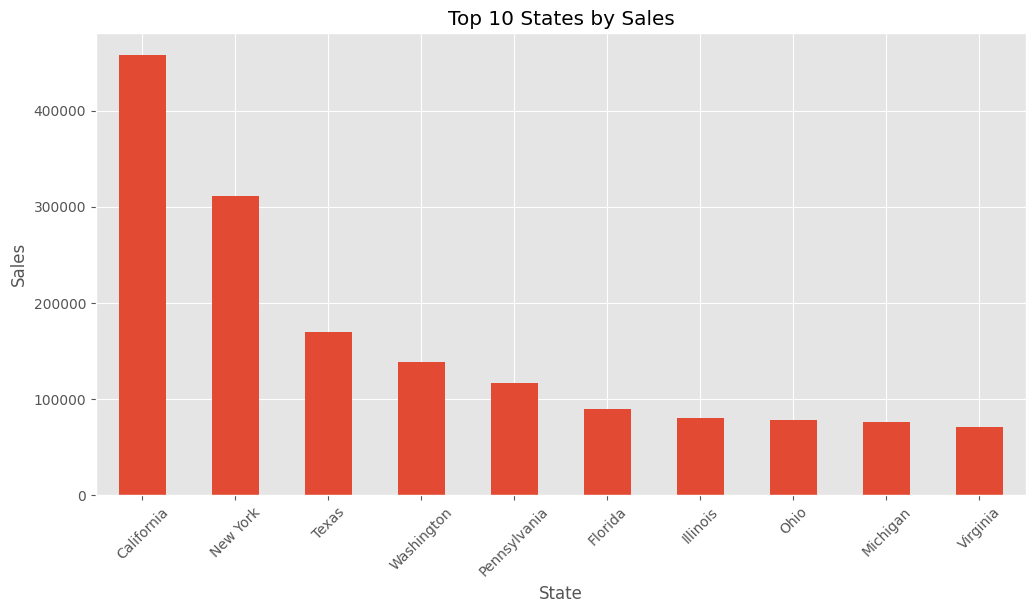

Ship Mode
First Class        48969.8399
Same Day           15891.7589
Second Class       57446.6354
Standard Class    164088.7875
Name: Profit, dtype: float64


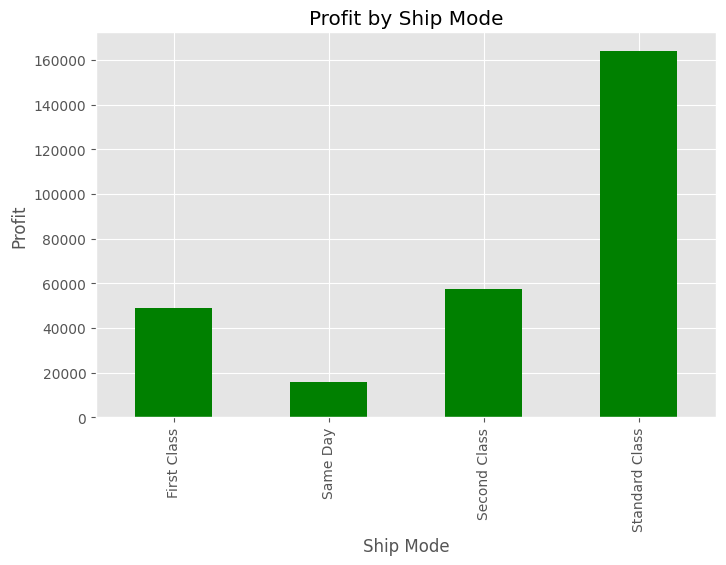

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


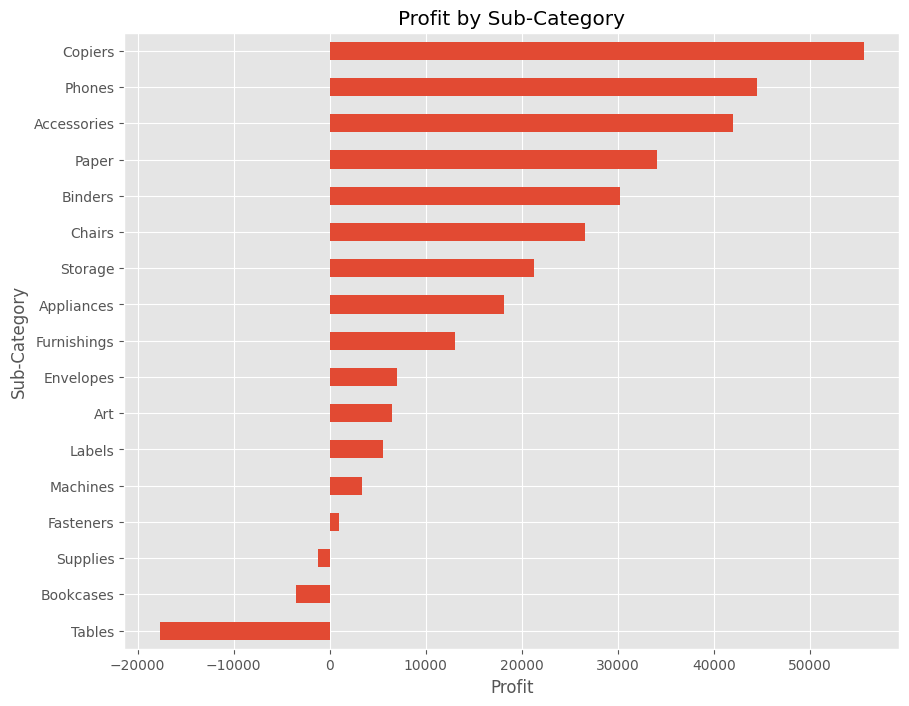


FINAL BUSINESS INSIGHTS

1. Technology category generated highest profit.
2. High discounts negatively impacted profit.
3. Furniture category contributed major losses.
4. Consumer segment produced strong sales.
5. Certain products consistently caused losses.
6. Some states generated much higher sales than others.
7. Monthly sales trends revealed seasonal patterns.
8. Standard shipping modes generated stable profits.
9. Some sub-categories are highly profitable while others are loss-making.
10. Data analysis helps businesses improve pricing, inventory, and strategy.

Project Analysis Completed Successfully!


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../DATA/Sample - Superstore.csv", encoding="cp1252")
print(df.head())
print(df.info())
print(df.describe())
print("Shape:", df.shape)
print(df.columns)

# Basic cleaning
print("Missing values:")
print(df.isnull().sum())
print("duplicated values:", df.duplicated().sum())
df = df.drop_duplicates()
print("After drop duplicates shape:", df.shape)
print(df.dtypes)

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
print(df.isnull().sum())

# Negative profit rows
n_profit = df[df['Profit'] < 0]
print(n_profit.head())
print("Negative profit rows:", n_profit.shape)

# Top sales
top_sales = df.sort_values(by='Sales', ascending=False)
print(top_sales[['Product Name','Sales']].head(10))

# Save cleaned data
df.to_csv("../Data/cleaned_suuperstore.csv", index=False)
print("DATA Cleaned successfully")

# SQLite export
conn = sqlite3.connect("../Data/superstore.db")
df.to_sql('sales', conn, if_exists='replace', index=False)
print("Data inserted into SQLite database successfully.")

# Sample queries
print(pd.read_sql("SELECT * FROM sales LIMIT 5", conn))
print(pd.read_sql("SELECT Region, Round(SUM(sales),2) AS Total_Sales FROM sales GROUP BY Region ORDER BY Total_Sales DESC", conn))
print(pd.read_sql("SELECT Category AS Category, Round(SUM(Sales),2) AS Total_Sales FROM sales GROUP BY Category ORDER BY Total_Sales DESC", conn))
print(pd.read_sql("SELECT [Product Name] AS Product_Name, ROUND(SUM(Profit),2) AS Total_Profit FROM sales GROUP BY [Product Name] HAVING Total_Profit < 0 ORDER BY Total_Profit ASC LIMIT 10", conn))

# Plot settings
plt.style.use('ggplot')

# Region sales
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)
region_sales.plot(kind='bar')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

# Category profit
category_profit = df.groupby('Category')['Profit'].sum()
print(category_profit)
category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.show()

# Sales vs Profit by category
category_sales = df.groupby('Category')['Sales'].sum()
comparison = pd.DataFrame({'Sales': category_sales, 'Profit': category_profit})
print(comparison)
comparison.plot(kind='bar', figsize=(10,6))
plt.title('Sales vs Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Monthly sales
df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

# Top products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)
top_products.plot(kind='bar')
plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.show()

    # Correlation heatmap
    correlation = df[['Sales','Profit','Quantity','Discount']].corr()
    print(correlation)
    plt.figure(figsize=(8,6))
    sns.heatmap(correlation, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()

    # Additional visualizations and insights
    region_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
    plt.title('Region Wise Sales')
    plt.ylabel('')
    plt.show()
    segment_profit = df.groupby('Segment')['Profit'].sum()
    print(segment_profit)
    segment_profit.plot(kind='bar', figsize=(7,5))
    plt.title('Profit by Customer Segment')
    plt.xlabel('Segment')
    plt.ylabel('Profit')
    plt.show()
    top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
    top_products.plot(kind='barh', figsize=(10,6))
    plt.title('Top 10 Products by Sales')
    plt.xlabel('Sales')
    plt.ylabel('Product Name')
    plt.show()
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df['Sales'])
    plt.title('Sales Outliers')
    plt.show()
    loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)
    print(loss_products)
    loss_products.plot(kind='barh', figsize=(10,6), color='red')
    plt.title('Top 10 Loss-Making Products')
    plt.xlabel('Loss')
    plt.ylabel('Product Name')
    plt.show()
    state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
    print(state_sales)
    state_sales.plot(kind='bar', figsize=(12,6))
    plt.title('Top 10 States by Sales')
    plt.xlabel('State')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.show()
    ship_mode_profit = df.groupby('Ship Mode')['Profit'].sum()
    print(ship_mode_profit)
    ship_mode_profit.plot(kind='bar', figsize=(8,5), color='green')
    plt.title('Profit by Ship Mode')
    plt.xlabel('Ship Mode')
    plt.ylabel('Profit')
    plt.show()
    sub_category_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
    print(sub_category_profit)
    sub_category_profit.plot(kind='barh', figsize=(10,8))
    plt.title('Profit by Sub-Category')
    plt.xlabel('Profit')
    plt.ylabel('Sub-Category')
    plt.show()
    print('''
    FINAL BUSINESS INSIGHTS

    1. Technology category generated highest profit.
    2. High discounts negatively impacted profit.
    3. Furniture category contributed major losses.
    4. Consumer segment produced strong sales.
    5. Certain products consistently caused losses.
    6. Some states generated much higher sales than others.
    7. Monthly sales trends revealed seasonal patterns.
    8. Standard shipping modes generated stable profits.
    9. Some sub-categories are highly profitable while others are loss-making.
    10. Data analysis helps businesses improve pricing, inventory, and strategy.
    ''')
    plt.savefig('final_chart.png')
    print("Project Analysis Completed Successfully!")